# Exploratory Data Analysis Report
**Objective: Uncover patterns, trends, and relationships in the sales data.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
%matplotlib inline

In [10]:
df = pd.read_csv("cleaned_dataset.csv")
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Year,Order_Month,Order_Month_name,Order_Weekday,Age_Group,Revenue_check
0,ORD100002,2025-02-25,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,February,Tuesday,26-35,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,October,Tuesday,56-65,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,May,Tuesday,56-65,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,December,Tuesday,56-65,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,November,Thursday,36-45,140365.90


In [11]:
print(df.shape)
df.info()

(1000, 18)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          1000 non-null   str           
 1   Order_Date        1000 non-null   datetime64[us]
 2   Customer_ID       1000 non-null   str           
 3   Customer_Name     1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Gender            1000 non-null   str           
 6   City              1000 non-null   str           
 7   Product           1000 non-null   str           
 8   Category          1000 non-null   str           
 9   Quantity          1000 non-null   int64         
 10  Unit_Price        1000 non-null   float64       
 11  Total_Sales       1000 non-null   float64       
 12  Order_Year        1000 non-null   int64         
 13  Order_Month       1000 non-null   int64         
 14  Order_Month_name  1000 no

In [14]:
df.isna().sum()

Order_ID            0
Order_Date          0
Customer_ID         0
Customer_Name       0
Age                 0
Gender              0
City                0
Product             0
Category            0
Quantity            0
Unit_Price          0
Total_Sales         0
Order_Year          0
Order_Month         0
Order_Month_name    0
Order_Weekday       0
Age_Group           0
Revenue_check       0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

## Descriptive Statistics — Numerical Columns

In [20]:
num_cols = ["Age","Quantity","Unit_Price","Total_Sales"]
desc = df[num_cols].describe().T
desc["mode"] = df[num_cols].mode().iloc[0]
desc

,count,mean,std,min,25%,50%,75%,max,mode
Age,1000.0,41.35300,13.683626,18.00,30.0000,41.000,53.0000,65.00,41.00
Quantity,1000.0,5.43500,2.838632,1.00,3.0000,5.000,8.0000,10.00,4.00
Unit_Price,1000.0,25486.78341,14179.402361,145.78,13895.7225,25398.740,37512.3825,49997.53,145.78
Total_Sales,1000.0,139399.43965,114100.051546,437.34,47066.6325,108594.025,203722.8825,493677.50,437.34


**Key numbers:**
- Average Total Sales ≈ ₹139,399 
- Average Quantity per order ≈ 5.4 units, ranging 1–10
- Average Unit Price ≈ ₹25,487, ranging ₹146 – ₹49,998
- Average customer Age ≈ 41 years, ranging 18–65

## Descriptive Statistics — Categorical Columns

In [26]:
for c in ["Gender", "City", "Category"]:
    print(f"---{c}---")
    print(df[c].value_counts())
    print(f"Most Common: {df[c].mode()[0]}\n")
    

---Gender---
Gender
Male      511
Female    489
Name: count, dtype: int64
Most Common: Male

---City---
City
Patna        148
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
Name: count, dtype: int64
Most Common: Patna

---Category---
Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64
Most Common: Electronics



## Univariate Visualizations

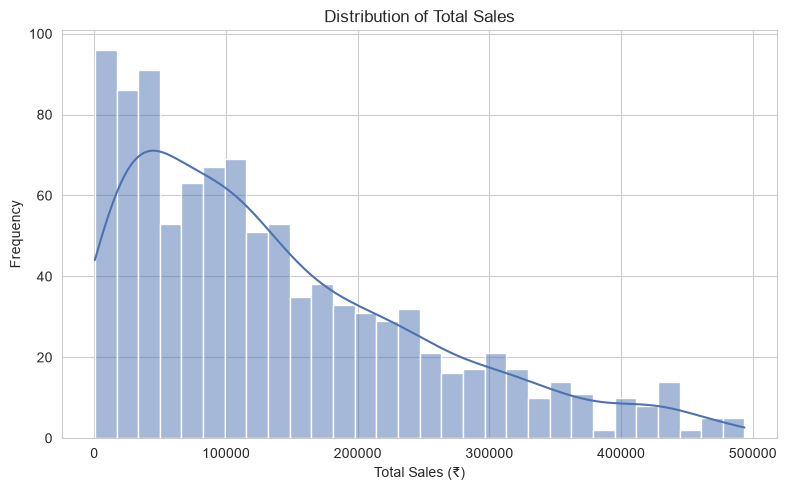

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df["Total_Sales"], bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales (₹)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

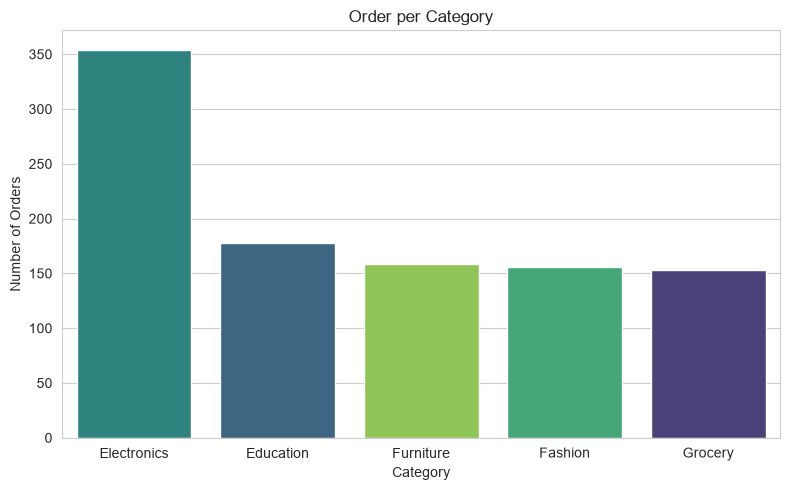

In [38]:
plt.figure(figsize=(8,5))
order = df["Category"].value_counts().index
sns.countplot(data=df, x="Category", order=order, hue="Category", palette="viridis", legend=False)
plt.title("Order per Category")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

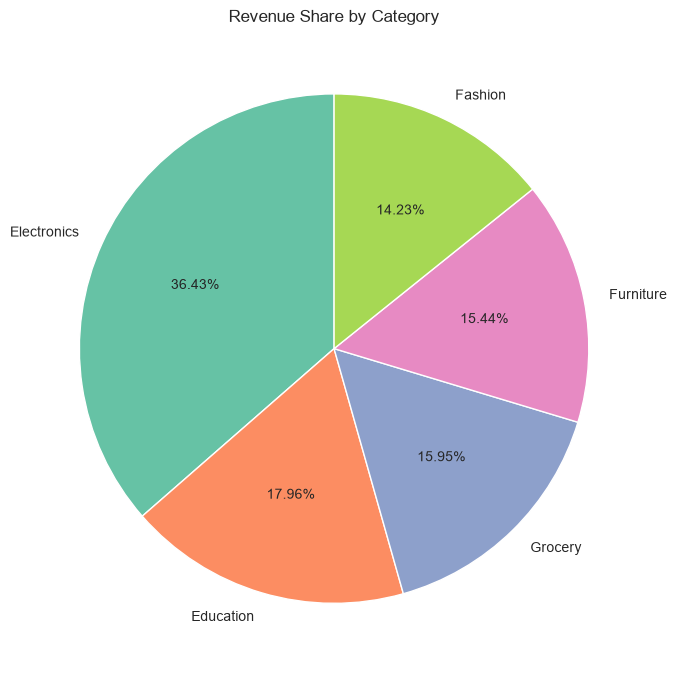

In [47]:
plt.figure(figsize=(7,7))
cat_rev = df.groupby("Category")["Total_Sales"].sum().sort_values(ascending=False)
plt.pie(cat_rev, labels=cat_rev.index, autopct="%1.2f%%", startangle=90, colors=sns.color_palette("Set2"))
plt.title("Revenue Share by Category")
plt.tight_layout()
plt.show()

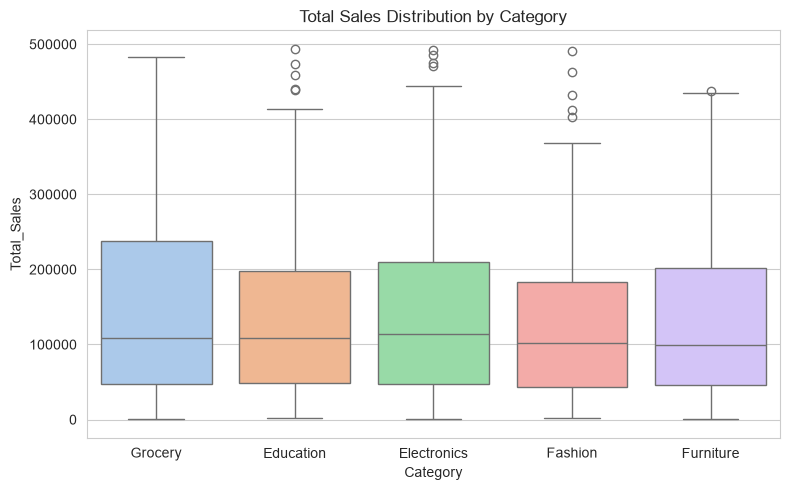

In [50]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Category", y="Total_Sales", hue="Category", palette="pastel", legend=False)
plt.title("Total Sales Distribution by Category")
plt.tight_layout()
plt.show()

## Multivariate Analysis & Correlation

In [51]:
corr = df[num_cols].corr()
corr

,Age,Quantity,Unit_Price,Total_Sales
Age,1.000000,-0.027666,-0.011955,0.001294
Quantity,-0.027666,1.000000,0.021855,0.646641
Unit_Price,-0.011955,0.021855,1.000000,0.686303
Total_Sales,0.001294,0.646641,0.686303,1.000000


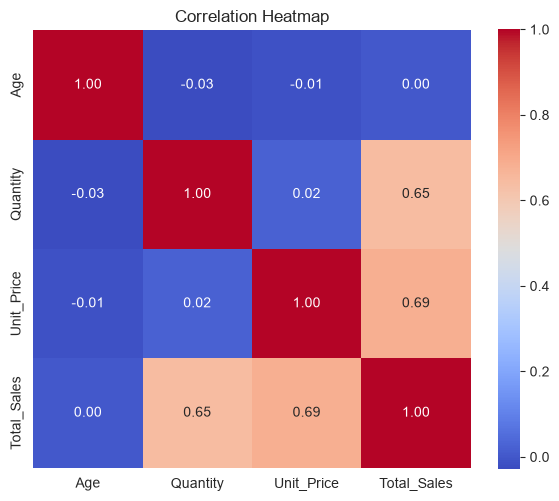

In [59]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Reading the correlations:**
- `Total_Sales` ↔ `Unit_Price` = **0.69** — price is the strongest single driver of order value.
- `Total_Sales` ↔ `Quantity` = **0.65** — quantity matters almost as much as price.
- `Age` is essentially uncorrelated with sales behavior (≈0), so customer age doesn't predict spend here

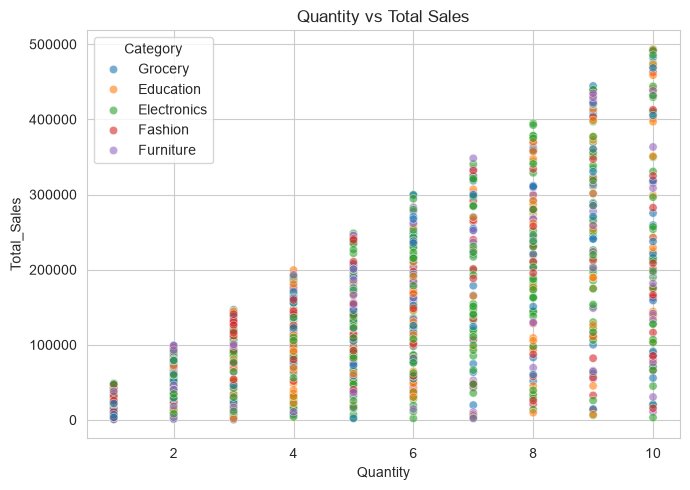

In [60]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Quantity", y="Total_Sales", hue="Category", alpha=0.6)
plt.title("Quantity vs Total Sales")
plt.tight_layout()
plt.show()

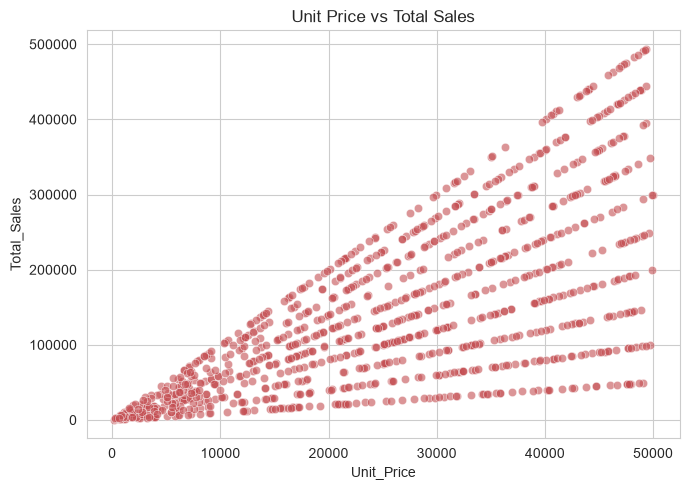

In [63]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Unit_Price", y="Total_Sales", color="#C44E52", alpha=0.6)
plt.title("Unit Price vs Total Sales")
plt.tight_layout()
plt.show()

In [65]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales', 'Order_Year', 'Order_Month', 'Order_Month_name',
       'Order_Weekday', 'Age_Group', 'Revenue_check'],
      dtype='str')

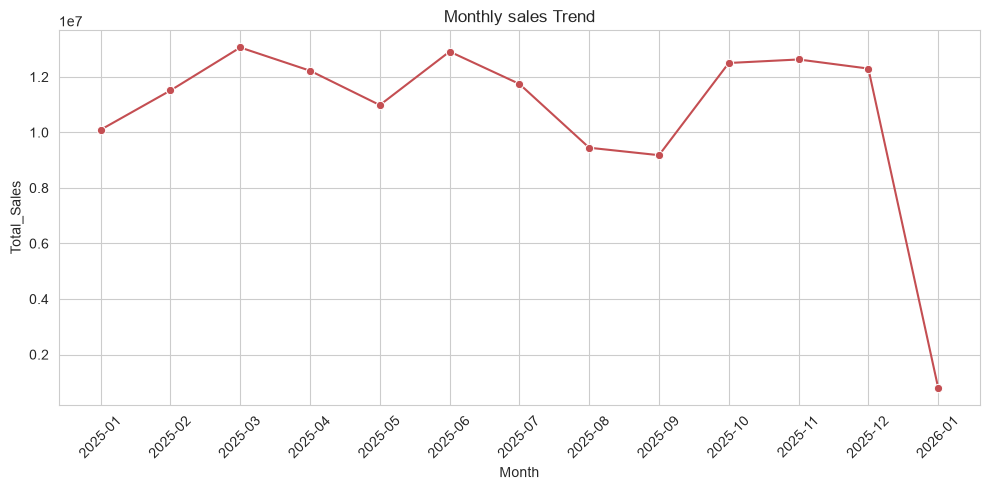

In [68]:
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)
monthly = df.groupby("Month")["Total_Sales"].sum().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly, x="Month", y="Total_Sales", marker="o", color="#C44E52")
plt.title("Monthly sales Trend")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.tight_layout()
plt.show()

## 6. Key Business Insights

1. **Electronics dominates revenue** — ~36% of total sales, roughly double the next category (Education).
2. **Order value is driven by price and quantity together** (r=0.69 and r=0.65) — bundling higher-quantity, higher-price items is the biggest lever for order value.
3. **Q4 is the strongest quarter** (₹3.74 Cr) while **Q3 dips** — worth investigating September's slowdown.
4. **Only 52 of 947 customers (~5.5%) are repeat buyers** — retention/loyalty is a clear growth opportunity.
5. **Patna, Kolkata, and Bengaluru lead by city**, but the spread across all 8 cities is fairly even, so demand isn't concentrated in one region.
6. **Male and female customers spend almost identically** (₹72.5M vs ₹66.9M total, in line with the 511/489 order split) — gender isn't a differentiator.